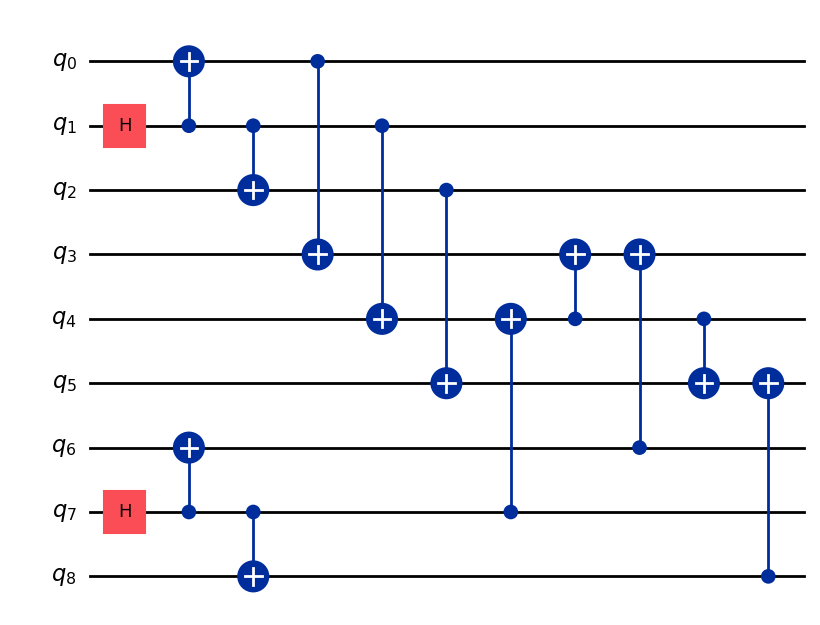

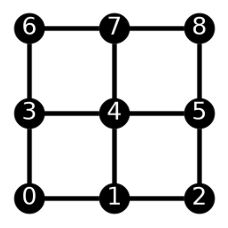

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_gate_map, plot_circuit_layout


qc = QuantumCircuit(9)

qc.h(1)
qc.cx(1, 0)
qc.cx(1, 2)
qc.cx(1, 4)

qc.h(7)
qc.cx(7, 6)
qc.cx(7, 8)
qc.cx(7, 4)

qc.cx(0, 3)
qc.cx(4, 3)
qc.cx(6, 3)

qc.cx(2, 5)
qc.cx(4, 5)
qc.cx(8, 5)

display(qc.draw('mpl'))

qc.measure_all()

backend = AerSimulator()

coupling_map = [[0,1], [0,3], [1,2], [1,4], [2, 5], [3, 4], [3,6], [4,5], [4,7], [5,8], [6,7], [7,8]]

testBackend = GenericBackendV2(num_qubits=9,coupling_map = coupling_map)

transpiled_circ = transpile(qc, testBackend)
# transpiled_circ.save_statevector()

# job = backend.run(transpiled_circ, shots=10000)
# result = job.result()

# counts = result.get_counts()
# data_counts = {}

# for key, val in counts.items():
#     reversed_key = key[::-1]
#     data = key[1:3]  
#     data_counts[data] = data_counts.get(data, 0) + val

# plot_distribution(data_counts)
plot_circuit_layout(transpiled_circ, testBackend, qubit_coordinates = [[0,0], [0,1],[0,2],[1,0], [1,1], [1,2], [2,0], [2,1], [2,2]])